In [1]:
from pyfmreader.hs3.parsehs3header import parseHS3header
import matplotlib.pyplot as plt
import numpy as np  

In [2]:
filepath = '/Users/evillz/Data/afm_fs_test_data/test/tdms_files/F_Curve_Basic_S4_100.00_25.tdms'
# file_metadata = parseHS3header(filepath)
# # show file metadata for loop
# for key, value in file_metadata.items():
#     print(f"{key}: {value}")


In [3]:
from pyfmreader import loadfile

In [4]:
file = loadfile(filepath, hs3_bool=True)
filemetadata = file.filemetadata

# print all filemetadata
for key, value in filemetadata.items():
    print(f"{key}: {value}")


file_path: /Users/evillz/Data/afm_fs_test_data/test/tdms_files/F_Curve_Basic_S4_100.00_25.tdms
params_file: System_Param.dat
params_folder: /Users/evillz/Data/afm_fs_test_data/test/tdms_files
file_size_bytes: 3527174
height_channel_key: Piezo
deflection_chanel_key: Deflection
defl_sens_nmbyV: 14.157
spring_const_Nbym: 0.1
invOLS_nm_per_V: 76.7
piezo_gain: 2.085
reading_sample_rate_Hz: 2000000.0
dec_factor_approach: 1000.0
dec_factor_contact: 1000.0
dec_factor_retract: 1.0
approach_points: 220
dwell_points: 200
retract_points: 220000
force_curve_type: 0
S1_ms: 10.0
S2_ms: 100.0
S3_ms: 100.0
S4_ms: 100.0
S5_ms: 10.0
num_segments: 3
isFV: False
file_type: HS3_laura.tdms


In [5]:
# Filemetadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel_key = filemetadata['height_channel_key']
deflection_channel_key = filemetadata['deflection_chanel_key']

defl_sens = file_deflection_sensitivity / 1e9 #m/V

print(f"Height channel: {height_channel_key}")
print(f"Deflection Sens.: {defl_sens} m/V")
print(f"spring_const_Nbym: {K} N/m")


Height channel: Piezo
Deflection Sens.: 1.4157e-08 m/V
spring_const_Nbym: 0.1 N/m


In [6]:
# Select curve by index

curve_idx = 0
force_curve = file.getcurve(curve_idx)
# Get segments and indentation
segs = force_curve.get_segments()
force_curve.preprocess_force_curve(defl_sens, height_channel_key)

final_nb_points = filemetadata['final_nb_points']
relative_SR = filemetadata['relative_sr']

# get details of retract segments
for segid, segment in segs:
    if segment.segment_type in ('Retract', 'Ret'):
        # print(f"Segment ID: {segid}, Type: {segment.segment_type}")
        relative_SR_ret = relative_SR[segid]
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K
        relative_SR_ret = relative_SR[segid]
        vel_ret_um_s = segment.velocity  # Convert from nm to um/s
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret 

print (f"velocity: {vel_ret_um_s} um/s")

velocity: 7.432012863111482 um/s


220000, 220000, 220000
Total length of the force curve without contact: 220020
220220 220220


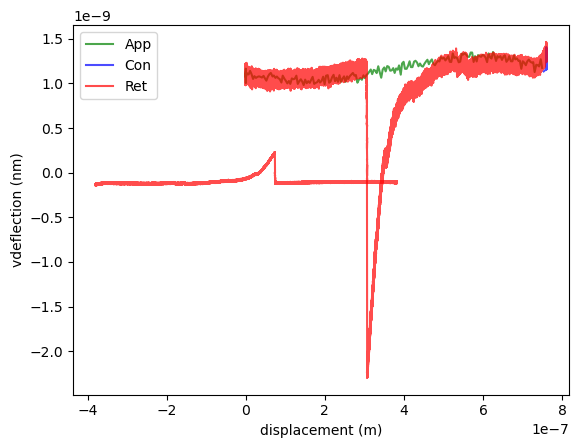

In [7]:
# Get zheight and vdeflection, for now only get retract
zmin_app = 0
show_plots = True
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection * K  # Convert to N
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K  # Convert to N
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
        print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
        if show_plots:
            plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Contact', 'Con', 'Pause'):
        con_piezo = -segment.zheight
        con_deflection = -segment.vdeflection * K  # Convert to N
        if show_plots:
            plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
if show_plots:
    plt.legend()
    plt.xlabel('displacement (m)')
    plt.ylabel('vdeflection (nm)')

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
print(f"Total length of the force curve without contact: {total_length}")


deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

plt.plot(ret_piezo[:], ret_deflection[:], 'r-', linewidth=1.5, label='Retract (reversed)', alpha=0.7)
plt.show()